In [ ]:
#1. Data Quality and Preparation

In [6]:
import os

path = r'C:\Users\Vivek Asus\OneDrive\Documents\GitHub\Hero-FinCorp-Analysis\Data'
print(os.listdir(path))


['applications.csv', 'branches.csv', 'customers.csv', 'defaults.csv', 'loans.csv']


In [9]:
import os

path = r'C:\Users\Vivek Asus\OneDrive\Documents\GitHub\Hero-FinCorp-Analysis\Data'

print("Folder exists:", os.path.exists(path))
print("Files inside folder:")
print(os.listdir(path))

Folder exists: True
Files inside folder:
['applications.csv', 'branches.csv', 'customers.csv', 'defaults.csv', 'loans.csv']


In [11]:
import pandas as pd
customers = pd.read_csv(r'C:\Users\Vivek Asus\OneDrive\Documents\GitHub\Hero-FinCorp-Analysis\Data\customers.csv')
loans = pd.read_csv(r'C:\Users\Vivek Asus\OneDrive\Documents\GitHub\Hero-FinCorp-Analysis\Data\loans.csv')
applications = pd.read_csv(r'C:\Users\Vivek Asus\OneDrive\Documents\GitHub\Hero-FinCorp-Analysis\Data\applications.csv')
transactions = pd.read_csv(r'C:\Users\Vivek Asus\OneDrive\Documents\GitHub\Hero-FinCorp-Analysis\Data\transactions.csv')
defaults = pd.read_csv(r'C:\Users\Vivek Asus\OneDrive\Documents\GitHub\Hero-FinCorp-Analysis\Data\defaults.csv')
branches = pd.read_csv(r'C:\Users\Vivek Asus\OneDrive\Documents\GitHub\Hero-FinCorp-Analysis\Data\branches.csv')

C:\Users\Vivek Asus\AppData\Local\Temp\ipykernel_13236\2799418861.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv(r'C:\Users\Vivek Asus\OneDrive\Documents\GitHub\Hero-FinCorp-Analysis\Data\applications.csv')


In [12]:
applications = pd.read_csv(
    r'C:\Users\Vivek Asus\OneDrive\Documents\GitHub\Hero-FinCorp-Analysis\Data\applications.csv',
    low_memory=False
)

In [ ]:
#understanding the data

In [13]:
customers.info()
loans.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Customer_ID              70000 non-null  object
 1   Full_Name                70000 non-null  object
 2   Contact_Number           70000 non-null  int64 
 3   Email                    70000 non-null  object
 4   Address                  70000 non-null  object
 5   Age                      70000 non-null  int64 
 6   Gender                   70000 non-null  object
 7   Marital_Status           70000 non-null  object
 8   Employment_Status        70000 non-null  object
 9   Annual_Income            70000 non-null  int64 
 10  Credit_Score             70000 non-null  int64 
 11  Region                   70000 non-null  object
 12  Account_Tenure           70000 non-null  object
 13  Relationship_Manager_ID  70000 non-null  object
dtypes: int64(4), object(10)
memory usage: 

,Loan_Amount,Interest_Rate,Loan_Term,Overdue_Amount,EMI_Amount
count,9.000000e+04,90000.000000,90000.000000,90000.000000,90000.000000
mean,2.516259e+06,11.005393,36.069867,12745.841511,50874.181444
std,1.429289e+06,2.307139,16.956931,16193.984497,28274.305704
min,5.002600e+04,7.000000,12.000000,0.000000,2001.000000
25%,1.275705e+06,9.000000,24.000000,0.000000,26229.750000
50%,2.510076e+06,11.010000,36.000000,1048.500000,50861.000000
75%,3.751702e+06,13.010000,48.000000,25433.000000,75431.250000
max,4.999958e+06,15.000000,60.000000,49999.000000,100000.000000


In [ ]:
#Data cleaning

In [14]:
# Missing values
customers.isnull().sum()

# Remove duplicates
customers.drop_duplicates(inplace=True)
loans.drop_duplicates(inplace=True)

# Convert dates
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'])
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'])
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'])

In [ ]:
#merge Data

In [15]:
df = loans.merge(customers, on='Customer_ID', how='left')
df = df.merge(branches, on='Branch_ID', how='left')

# Default flag
df['Default_Flag'] = df['Loan_ID'].isin(defaults['Loan_ID']).astype(int)

KeyError: 'Branch_ID'

In [16]:
print(df.columns)
print(branches.columns)

Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Full_Name', 'Contact_Number', 'Email', 'Address', 'Age', 'Gender',
       'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score',
       'Region', 'Account_Tenure', 'Relationship_Manager_ID'],
      dtype='object')
Index(['Branch_ID', 'Branch_Name', 'Region', 'Total_Customers',
       'Total_Active_Loans', 'Delinquent_Loans', 'Loan_Disbursement_Amount',
       'Avg_Processing_Time', 'Relationship_Manager_Count'],
      dtype='object')


In [17]:
branches['Default_Rate'] = branches['Delinquent_Loans'] / branches['Total_Active_Loans']

In [18]:
df = loans.merge(customers, on='Customer_ID', how='left')

In [19]:
df.head()
df.shape

(90000, 25)

In [20]:
# Interest income
df['Interest_Income'] = df['Loan_Amount'] * df['Interest_Rate'] * df['Loan_Term']/12

# EMI (approx formula)
df['EMI'] = (df['Loan_Amount'] * df['Interest_Rate']/12)

# EMI to income
df['EMI_to_Income'] = df['EMI'] / df['Annual_Income']

In [21]:
df[['Loan_Amount','Interest_Rate','EMI','EMI_to_Income','Interest_Income']].head()

,Loan_Amount,Interest_Rate,EMI,EMI_to_Income,Interest_Income
0,4030468,8.45,2.838121e+06,4.475812,6.811491e+07
1,3498647,11.90,3.469492e+06,3.624069,1.665356e+08
2,4871438,9.74,3.953984e+06,6.137658,9.489561e+07
3,541515,13.55,6.114607e+05,0.314103,1.467506e+07
4,631036,10.10,5.311220e+05,2.162320,1.912039e+07


In [ ]:
#2.Descriptive Analysis

In [ ]:
####1. Distribution Analysis

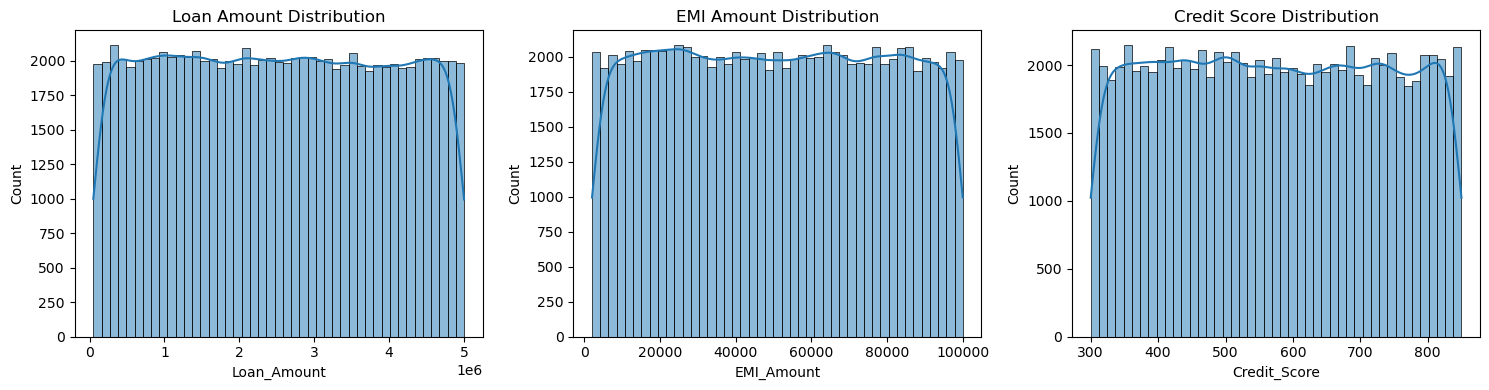

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,4))

# Loan Amount
plt.subplot(1,3,1)
sns.histplot(df['Loan_Amount'], kde=True)
plt.title("Loan Amount Distribution")

# EMI Amount
plt.subplot(1,3,2)
sns.histplot(df['EMI_Amount'], kde=True)
plt.title("EMI Amount Distribution")

# Credit Score
plt.subplot(1,3,3)
sns.histplot(df['Credit_Score'], kde=True)
plt.title("Credit Score Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# all of these looks same, they are flat, they are bit unclear

In [ ]:
#lets check this in a different way, loan amount density

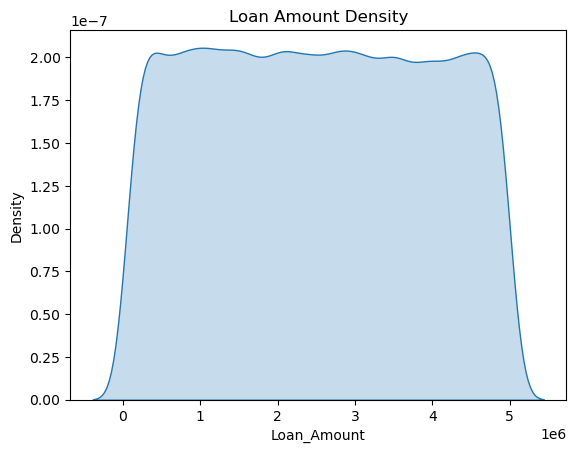

In [41]:
sns.kdeplot(df['Loan_Amount'], fill=True)
plt.title("Loan Amount Density")
plt.show()

In [ ]:
### Insight:

- The loan amount distribution appears relatively uniform across the range  
- There is no strong concentration in any specific loan size segment  
- This suggests a diversified loan portfolio without heavy bias toward small or large loans  

### Business Interpretation:

- Risk is spread across different loan sizes rather than concentrated  
- However, distribution alone does not explain default risk  
- Further segmentation (e.g., loan amount vs default) is required to identify risk patterns

In [ ]:
###Credit Score vs Default###

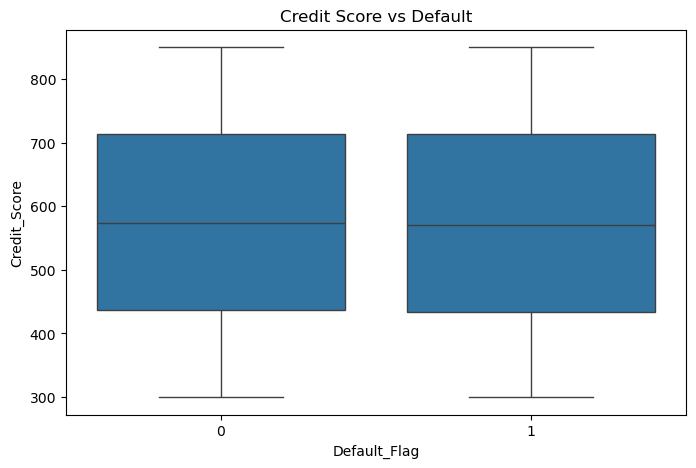

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Default_Flag', y='Credit_Score', data=df)
plt.title("Credit Score vs Default")
plt.show()

In [ ]:
### Insight:

- The distribution of credit scores is very similar for both defaulters and non-defaulters  
- There is no strong visible separation between the two groups  
- This suggests that credit score alone is not a strong predictor of default in this dataset  

### Business Interpretation:

- Default risk is likely influenced by multiple factors rather than the credit score alone  
- Additional variables such as EMI burden, income level, and loan characteristics should be analysed  

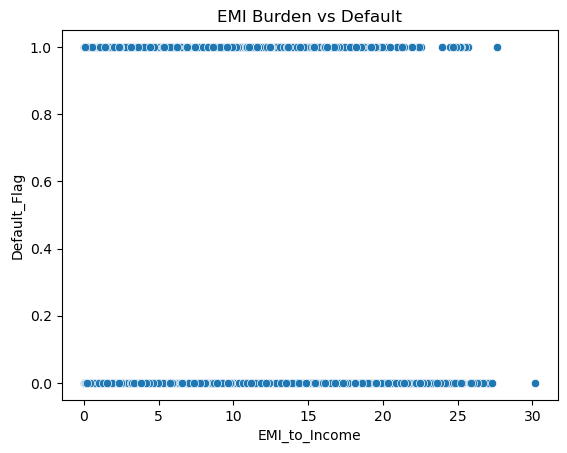

In [46]:
sns.scatterplot(x='EMI_to_Income', y='Default_Flag', data=df)
plt.title("EMI Burden vs Default")
plt.show()

In [ ]:
##insights for EMI Burden vs Default
- No clear relationship between EMI-to-income ratio and default probability  
- Default occurs across all EMI burden levels  
- EMI burden alone is not a strong predictor of default in this dataset  

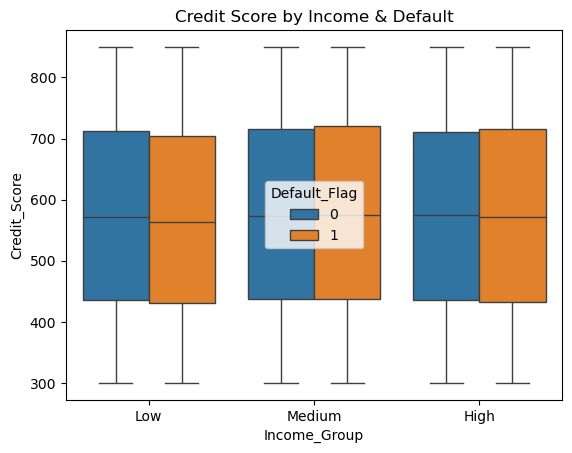

In [47]:
sns.boxplot(x='Income_Group', y='Credit_Score', hue='Default_Flag', data=df)
plt.title("Credit Score by Income & Default")
plt.show()

In [ ]:
##insights for Credit score by Income & Default
- Credit score distribution is similar across income groups and default status  
- Income level does not significantly differentiate credit risk in this dataset  
- Suggests weak interaction between income and credit score in predicting default  

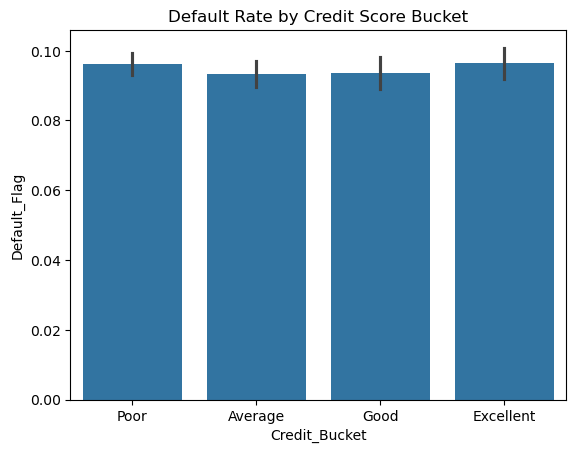

In [48]:
df['Credit_Bucket'] = pd.cut(df['Credit_Score'],
                            bins=[300,500,650,750,850],
                            labels=['Poor','Average','Good','Excellent'])

sns.barplot(x='Credit_Bucket', y='Default_Flag', data=df)
plt.title("Default Rate by Credit Score Bucket")
plt.show()

In [ ]:
#insights for Default rate by credit score bucket
- Default rate is consistent across all credit score buckets  
- Credit score does not significantly influence default probability  
- Indicates absence of risk differentiation based on credit score  

In [ ]:
##Payment Behavior Analysis

In [52]:
transactions.groupby('Payment_Type')['Amount'].agg(['mean','count']).sort_values(by='count', ascending=False)

,mean,count
Payment_Type,,
Penalty,25492.539807,247844
EMI,25500.319705,247156


In [ ]:
##Overdue Fee Analysis

In [53]:
transactions['Overdue_Fee'].describe()

count    495000.000000
mean       1273.332887
std        1619.499932
min           0.000000
25%           0.000000
50%           0.000000
75%        2539.000000
max        5000.000000
Name: Overdue_Fee, dtype: float64

In [ ]:
### Insight:

- A large proportion of transactions (over 50%) have zero overdue fees, indicating strong repayment behavior among a majority of customers  
- However, a smaller segment of customers shows significantly high overdue fees  
- The distribution is highly skewed, with a minority of customers contributing disproportionately to overdue amounts  

### Business Interpretation:

- Default risk is concentrated in a small subset of customers rather than evenly distributed  
- These high-overdue customers represent a critical risk segment that requires targeted intervention  
- Monitoring overdue fee patterns can serve as an early warning signal for potential defaults  

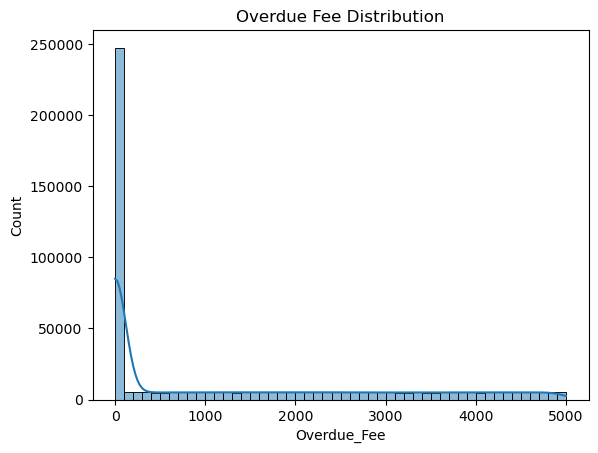

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(transactions['Overdue_Fee'], bins=50, kde=True)
plt.title("Overdue Fee Distribution")
plt.show()

In [ ]:
##Insights
- A significant proportion of customers have zero overdue fees, indicating strong repayment behavior  
- The distribution is highly right-skewed, with a small segment of customers incurring high overdue fees  
- This suggests that financial risk is concentrated among a minority of customers  

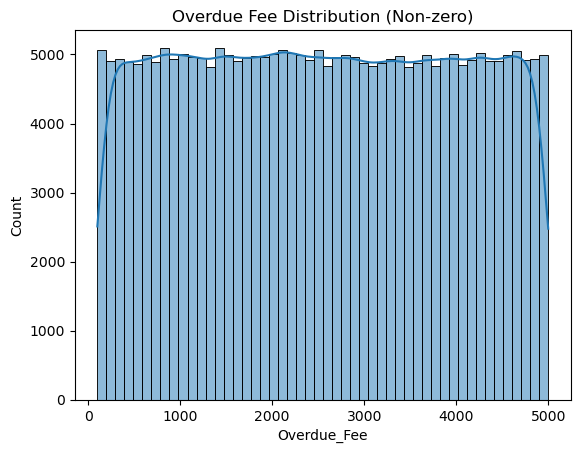

In [55]:
sns.histplot(transactions[transactions['Overdue_Fee'] > 0]['Overdue_Fee'], bins=50, kde=True)
plt.title("Overdue Fee Distribution (Non-zero)")
plt.show()

In [ ]:
#insights
- Among customers with overdue fees, the distribution is relatively uniform  
- No specific overdue level dominates  
- This suggests that once customers start missing payments, severity varies widely without a clear pattern  

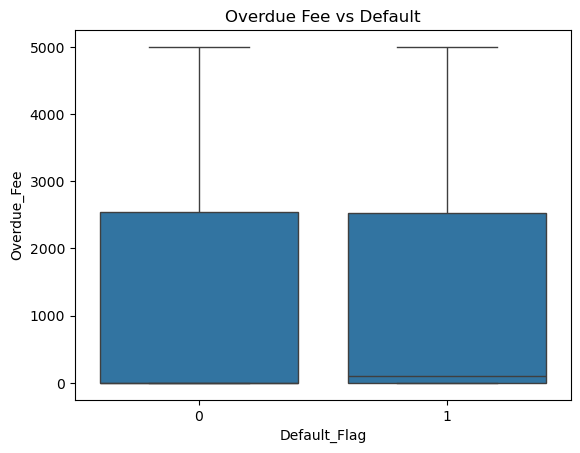

In [56]:
trans_df = transactions.merge(df[['Loan_ID','Default_Flag']], on='Loan_ID', how='left')

sns.boxplot(x='Default_Flag', y='Overdue_Fee', data=trans_df)
plt.title("Overdue Fee vs Default")
plt.show()

In [ ]:
##Insight
-Overdue fee is NOT strongly differentiating defaulters

In [ ]:
##Regional Trends (Disbursement + Defaults)

In [57]:
regional = df.groupby('Region').agg({
    'Loan_Amount': 'sum',
    'Default_Flag': 'mean'
}).reset_index()

regional.rename(columns={
    'Loan_Amount': 'Total_Disbursement',
    'Default_Flag': 'Default_Rate'
}, inplace=True)

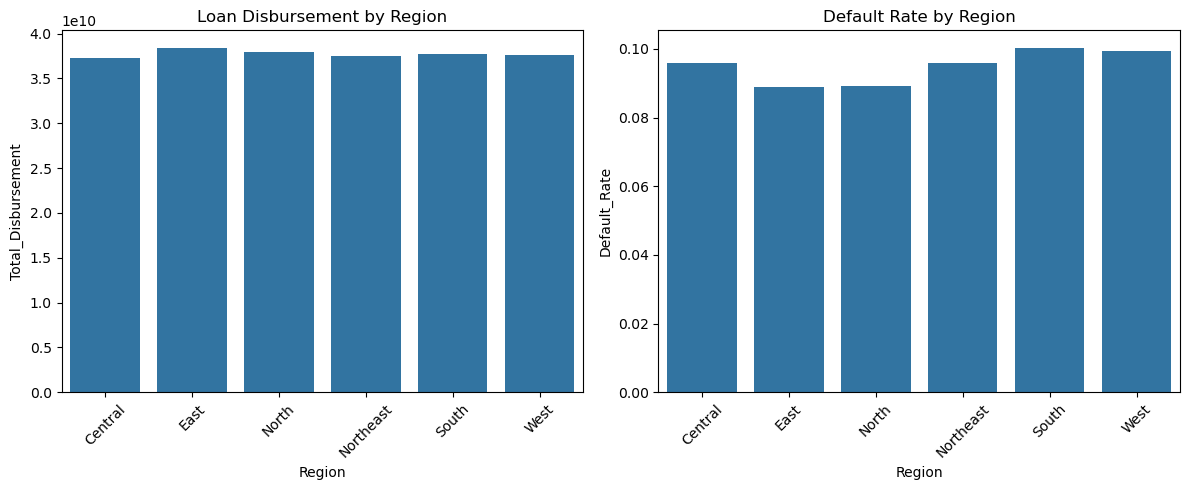

In [58]:
plt.figure(figsize=(12,5))

# Disbursement
plt.subplot(1,2,1)
sns.barplot(x='Region', y='Total_Disbursement', data=regional)
plt.xticks(rotation=45)
plt.title("Loan Disbursement by Region")

# Default Rate
plt.subplot(1,2,2)
sns.barplot(x='Region', y='Default_Rate', data=regional)
plt.xticks(rotation=45)
plt.title("Default Rate by Region")

plt.tight_layout()
plt.show()

In [ ]:
## Insights

- Loan disbursement is evenly distributed across all regions  
- No single region contributes disproportionately to the loan portfolio  
- Indicates a geographically diversified lending strategy  

### Business Interpretation:
- Risk exposure is evenly spread across regions  
- Reduces dependency on any single geographic market  

In [ ]:
###Monthly Trends (Applications + Disbursement)

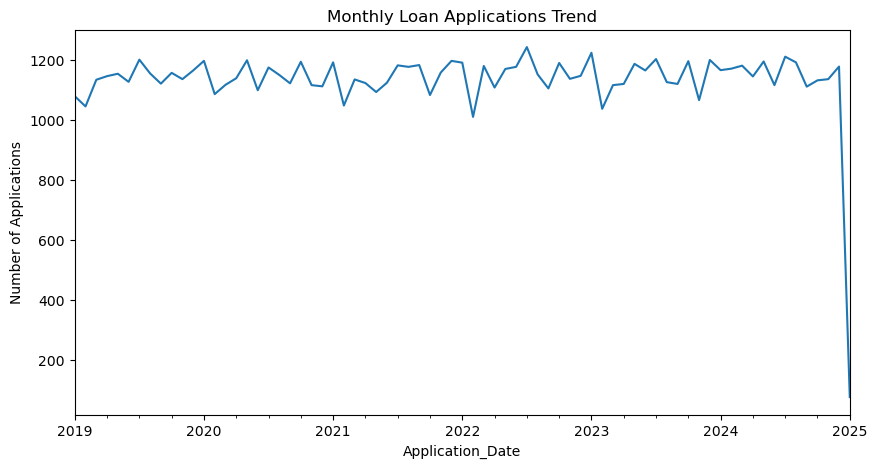

In [59]:
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'])

monthly_apps = applications.groupby(applications['Application_Date'].dt.to_period('M')).size()

monthly_apps.plot(figsize=(10,5))
plt.title("Monthly Loan Applications Trend")
plt.ylabel("Number of Applications")
plt.show()

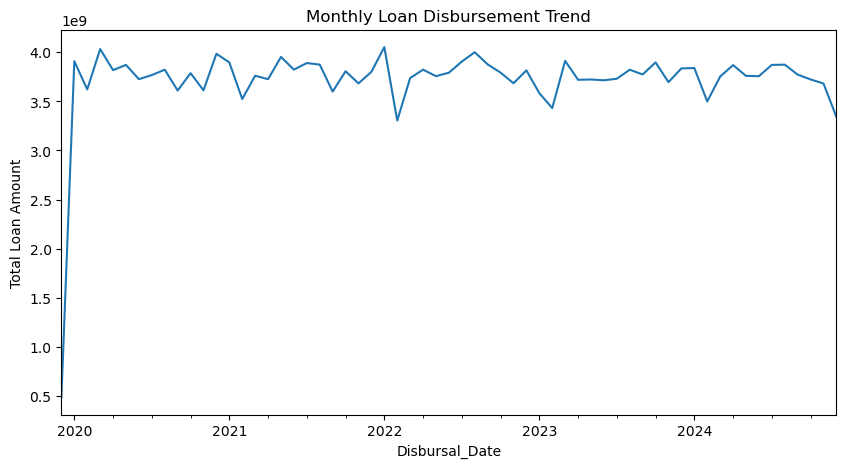

In [60]:
df['Disbursal_Date'] = pd.to_datetime(df['Disbursal_Date'])

monthly_disb = df.groupby(df['Disbursal_Date'].dt.to_period('M'))['Loan_Amount'].sum()

monthly_disb.plot(figsize=(10,5))
plt.title("Monthly Loan Disbursement Trend")
plt.ylabel("Total Loan Amount")
plt.show()

In [ ]:
##Insights

- Default rates are relatively consistent across all regions  
- Minor variations exist but no region stands out as significantly high-risk  

### Business Interpretation:
- Geographic location is not a strong driver of default risk in this dataset  
- Regional performance is stable, suggesting uniform credit policy implementation  

In [ ]:
#EDA

In [ ]:
1. Loan Distribution

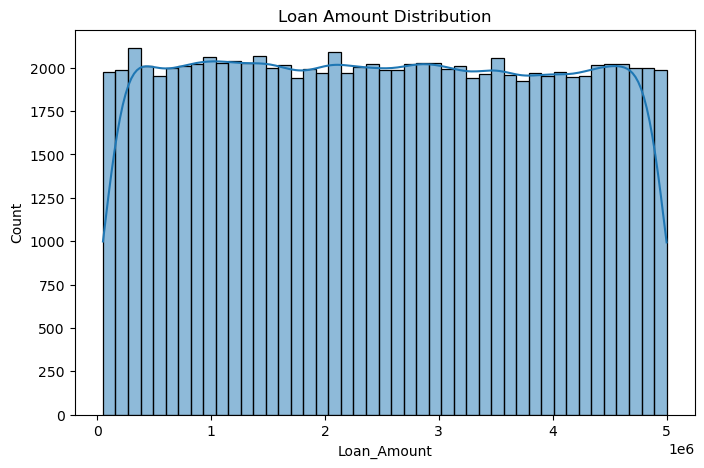

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Loan_Amount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

In [ ]:
2. Credit Score vs Default

In [23]:
sns.boxplot(x='Default_Flag', y='Credit_Score', data=df)
plt.title("Credit Score vs Default")
plt.show()

ValueError: Could not interpret value `Default_Flag` for `x`. An entry with this name does not appear in `data`.

In [24]:
df['Default_Flag'] = df['Loan_ID'].isin(defaults['Loan_ID']).astype(int)

In [25]:
df.columns

Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Full_Name', 'Contact_Number', 'Email', 'Address', 'Age', 'Gender',
       'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score',
       'Region', 'Account_Tenure', 'Relationship_Manager_ID',
       'Interest_Income', 'EMI', 'EMI_to_Income', 'Default_Flag'],
      dtype='object')

In [26]:
df['Default_Flag'] = df['Loan_ID'].isin(defaults['Loan_ID']).astype(int)

In [27]:
df[['Loan_ID','Default_Flag']].head()

,Loan_ID,Default_Flag
0,L000001,0
1,L000002,0
2,L000003,0
3,L000004,0
4,L000005,0


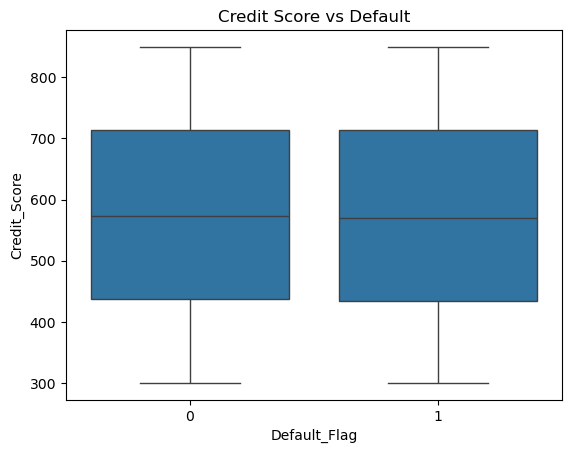

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Default_Flag', y='Credit_Score', data=df)
plt.title("Credit Score vs Default")
plt.show()

In [ ]:
#3. Correlation Heatmap

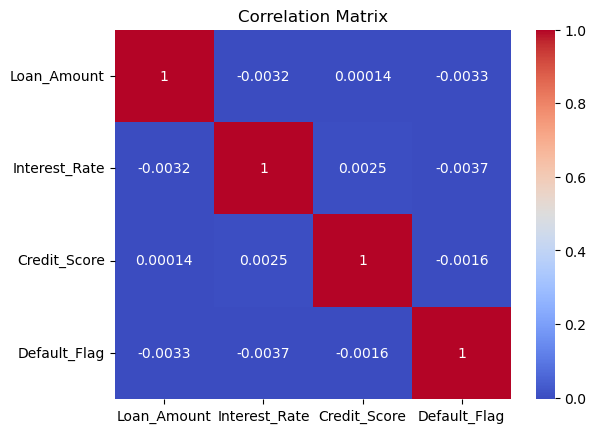

In [29]:
corr = df[['Loan_Amount','Interest_Rate','Credit_Score','Default_Flag']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
#Default Risk Analysis

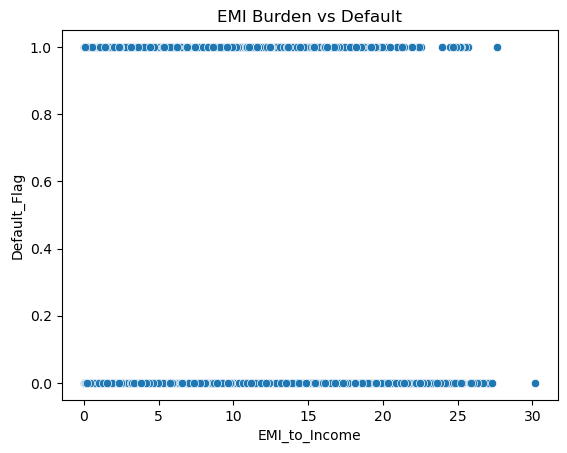

In [30]:
sns.scatterplot(x='EMI_to_Income', y='Default_Flag', data=df)
plt.title("EMI Burden vs Default")
plt.show()

In [ ]:
#Branch Analysis

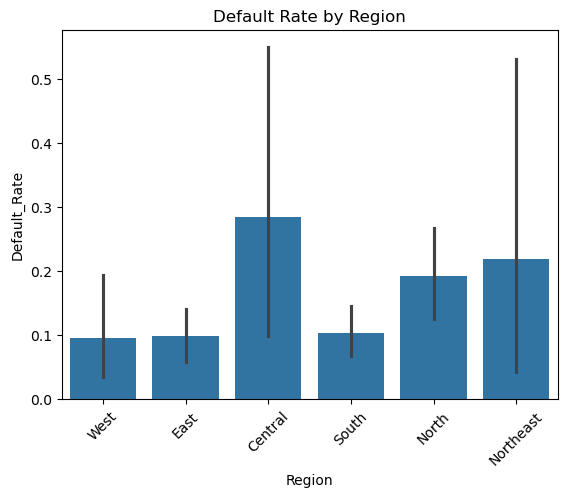

In [31]:
branches['Default_Rate'] = branches['Delinquent_Loans'] / branches['Total_Active_Loans']

sns.barplot(x='Region', y='Default_Rate', data=branches)
plt.xticks(rotation=45)
plt.title("Default Rate by Region")
plt.show()

In [ ]:
#Customer Segmentation

In [32]:
customers['Income_Group'] = pd.qcut(customers['Annual_Income'], 3, labels=['Low','Medium','High'])

seg = df.groupby('Income_Group')['Default_Flag'].mean()
print(seg)

KeyError: 'Income_Group'

In [33]:
customers['Income_Group'] = pd.qcut(customers['Annual_Income'], 3, labels=['Low','Medium','High'])

seg = df.groupby('Income_Group')['Default_Flag'].mean()
print(seg)

KeyError: 'Income_Group'

In [34]:
df['Income_Group'] = pd.qcut(df['Annual_Income'], 3, labels=['Low','Medium','High'])

In [35]:
seg = df.groupby('Income_Group')['Default_Flag'].mean()
print(seg)

Income_Group
Low       0.095600
Medium    0.097027
High      0.092006
Name: Default_Flag, dtype: float64


C:\Users\Vivek Asus\AppData\Local\Temp\ipykernel_13236\1249218746.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg = df.groupby('Income_Group')['Default_Flag'].mean()


In [36]:
df[['Annual_Income','Income_Group']].head()

,Annual_Income,Income_Group
0,634102,Low
1,957347,Medium
2,644217,Low
3,1946687,High
4,245626,Low


In [ ]:
#Recovery Analysis

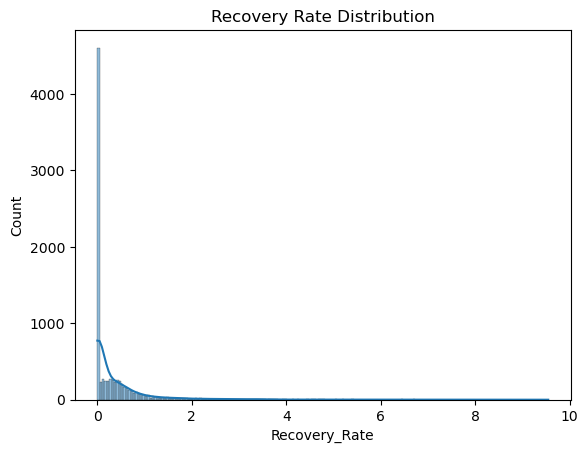

In [37]:
defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']

sns.histplot(defaults['Recovery_Rate'], kde=True)
plt.title("Recovery Rate Distribution")
plt.show()

In [ ]:
#Time Series

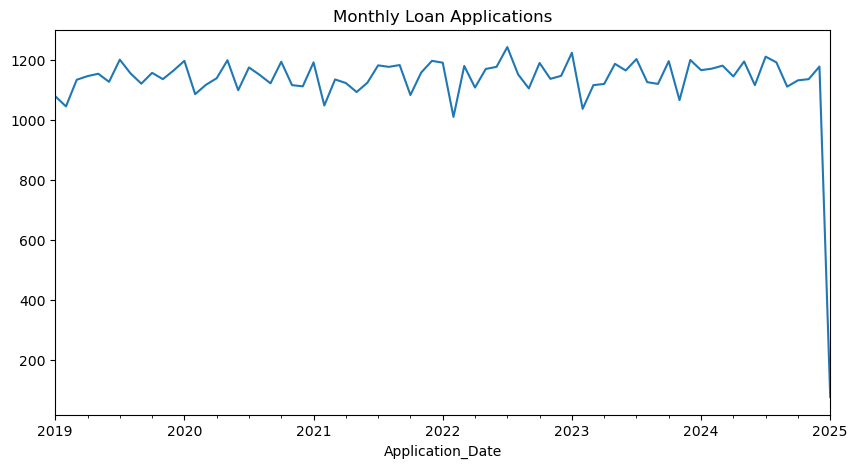

In [38]:
monthly = applications.groupby(applications['Application_Date'].dt.to_period('M')).size()

monthly.plot(figsize=(10,5))
plt.title("Monthly Loan Applications")
plt.show()